In [1]:
import sys; from pathlib import Path;
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = Path(src_dir.parents[0])
from imports import * ; current_dir = Path().resolve()  ; parent_dir = current_dir.parents[1]
one_drive_dir = mi.Utilities.get_one_drive_dir()

In [ ]:
data_dir =one_drive_dir.joinpath(r'General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 Thermostability/Anti-utag-FB_cd/Anti-Utag-FB CD.xlsx')
data = pd.read_excel(data_dir, sheet_name=None)

# results folder
results_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 Thermostability')
results_dir.mkdir(parents=True, exist_ok=True)

# convert the data to a pandas DataFrame
data = {sheet_name: pd.read_excel(data_dir, sheet_name='Sheet1') for sheet_name in data.keys()}
df = data['Sheet1']
df

# interpret the first row as the header
df.columns = df.iloc[0]
df = df[1:]

# split the dataframe into two dataframes. From column 0 to 5 is the first dataframe, from column 7 to 11 is the second dataframe
df_utag = df.iloc[:, 0:6]
df_utag_c_free = df.iloc[:, 7:13]


In [3]:
def plot_temperature_vs_ellipticity(
    df, 
    x_label='Temperature', 
    y_label='Ellipticity (216 nm)', 
    title='Temperature vs. Ellipticity at 216 nm',
    figsize=(7, 5),
    tick_size=12,
    plot_name='Temperature_vs_ellipticity',
    save_dir=Path('.'),
    use_sigmoid=True,
    marker_size=50
):
    """
    Plot each repetition of Temperature vs. Ellipticity and fit individually.
    Returns a list of x-values (inflection points) where each fit reaches half its amplitude.
    """
    # Ensure save directory exists
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    #cmap = plt.get_cmap('tab20')

    # Check for even number of columns
    if df.shape[1] % 2 != 0:
        raise ValueError("Expected an even number of columns (Temperature / ellipticity pairs).")
    n_reps = df.shape[1] // 2

    # Gray palette for points; reuse same for lines
    #colors = sns.color_palette("gray", n_colors=n_reps)
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(n_reps)]

    # Define the 4‑parameter sigmoid with offset
    def sigmoid_offset(x, a, b, c, d):
        # d = lower asymptote, a = amplitude above d
        return d + a / (1.0 + np.exp(-b * (x - c)))

    # Will collect the half‑max (inflection) x for each rep
    half_max_xs = []

    # Loop over each repetition
    for rep in range(n_reps):
        # Extract data for this repetition
        x = df.iloc[:, rep*2].to_numpy().astype(float)
        y = df.iloc[:, rep*2 + 1].to_numpy().astype(float)

        # Scatter the raw points
        col = colors[rep]
        ax.scatter(x, y,
                   color=col,
                   s=marker_size,
                   alpha=0.6,)
                   #label=f'Rep {rep+1}')

        # Sort data by x for fitting
        sort_idx   = np.argsort(x)
        x_fit_data = x[sort_idx]
        y_fit_data = y[sort_idx]

        # Robust initial guesses via percentiles
        d_guess = np.nanpercentile(y_fit_data, 1)   # lower asymptote ~ 1st percentile
        y99     = np.nanpercentile(y_fit_data, 99)  # near upper plateau
        a_guess = y99 - d_guess                     # amplitude
        b_guess = 1.0                               # slope
        # midpoint = x where y crosses halfway between plateaus
        midpoint = d_guess + a_guess/2.0
        c_guess = 60 #x_fit_data[np.nanargmin(np.abs(y_fit_data - midpoint))]

        # Fit
        try:
            popt, _ = curve_fit(
                sigmoid_offset,
                x_fit_data,
                y_fit_data,
                p0=[a_guess, b_guess, c_guess, d_guess],
                maxfev=20000  # allow more function evals
            )

            # popt = [a, b, c, d] → c is the inflection / half-max x
            half_x = popt[2]
            half_max_xs.append(half_x)
            print(f"Rep {rep+1}: half‑max at x = {half_x:.2f}")

            # Generate smooth curve
            x_line = np.linspace(x_fit_data.min(), x_fit_data.max(), 200)
            y_line = sigmoid_offset(x_line, *popt)
            #if rep == 1:
            ax.plot(x_line, y_line,
                    color=col,       # same color as points
                    linewidth=2.5,
                    # add the melting temperature to the label
                    label=f'Fit Rep {rep+1} (Tm = {half_x:.2f})'
                    #label=f'Tm = {half_x:.2f}')
                #label=f'Fit Rep {rep+1}')
            )
        except RuntimeError:
            # if fit fails, record NaN and continue
            half_max_xs.append(np.nan)
            print(f"Warning: fit failed for repetition {rep+1}")

    # Final styling
    ax.set_xlabel(x_label, fontsize=tick_size+2, fontname="Arial", color='black')
    ax.set_ylabel(y_label, fontsize=tick_size+2, fontname="Arial", color='black')
    ax.set_title(title, fontsize=tick_size+4, fontname="Arial", color='black')
    ax.tick_params(axis='both', labelsize=tick_size, colors='black')
    ax.grid(False)

    show_legend = False
    if show_legend:
        ax.legend(fontsize=tick_size-2, loc='upper left', frameon=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.25)

    plt.tight_layout()
    plt.savefig(save_dir / f"{plot_name}.png", dpi=600, bbox_inches='tight')
    plt.savefig(save_dir / f"{plot_name}.svg", dpi=600, bbox_inches='tight')
    plt.show()

    return half_max_xs

Rep 1: half‑max at x = 66.02
Rep 2: half‑max at x = 66.40
Rep 3: half‑max at x = 67.86


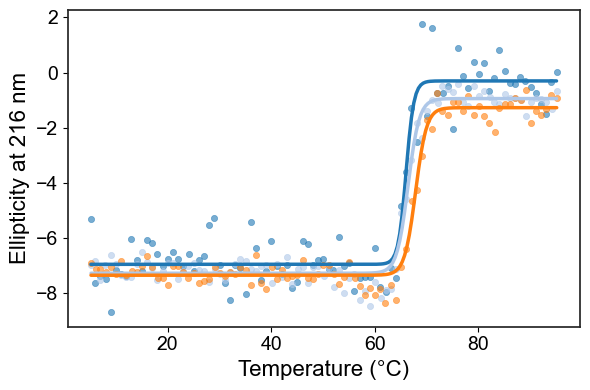

In [4]:
half_max_xs_utag = plot_temperature_vs_ellipticity(df_utag, 
                                x_label="Temperature (°C)", 
                                y_label="Ellipticity at 216 nm",
                                title="",
                                figsize=(6, 4),
                                tick_size=14,
                                plot_name='Temperature_vs_Ellipticity_Utag',
                                save_dir =results_dir,
                                use_sigmoid=True,
                                marker_size=20)

In [5]:
data = [66.02,66.40,67.86]
mean = np.mean(data)
std = np.std(data)
sem = std / np.sqrt(len(data))
print(f"Mean: {mean:.2f} ± {std:.2f}", f"SEM: {sem:.2f}")

Mean: 66.76 ± 0.79 SEM: 0.46


Rep 1: half‑max at x = 79.30
Rep 2: half‑max at x = 79.17
Rep 3: half‑max at x = 81.13


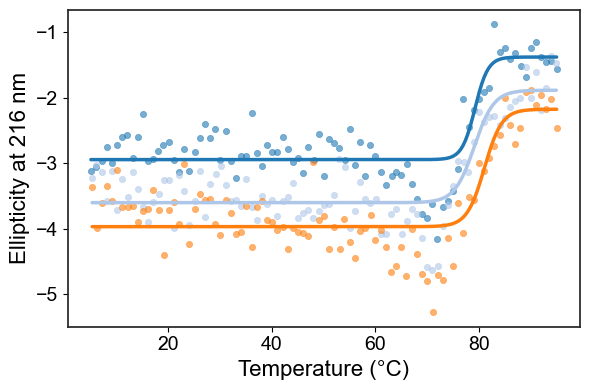

In [6]:
half_max_xs_utag_cf = plot_temperature_vs_ellipticity(df_utag_c_free,
                                x_label="Temperature (°C)", 
                                y_label="Ellipticity at 216 nm",
                                title="",
                                figsize=(6, 4),
                                tick_size=14,
                                plot_name='Temperature_vs_Ellipticity_Utag_c_free',
                                save_dir =results_dir,  
                                use_sigmoid=True,
                                marker_size=20)

In [7]:
data= [ 79.30, 79.17, 81.13]
mean = np.mean(data)
std = np.std(data)
sem = std / np.sqrt(len(data))
print(f"Mean: {mean:.2f} ± {std:.2f}", f"SEM: {sem:.2f}")

Mean: 79.87 ± 0.89 SEM: 0.52
